In [1]:
import cafe

img_dir = "./img/26.01.30-milestone_figure"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
fadata = cafe.data.read_h5ad("tmp/dynverse_bifurcating_1.h5ad")
fadata

AnnData object with n_obs × n_vars = 926 × 1128
    obs: 'c', 'group_onto_ref'
    var: 'feature_id', 'housekeeping'
    uns: 'cafe', 'group_onto_ref_colors', 'id'
    obsm: 'X_dynverse'
    layers: 'counts', 'expression'

array([[<Axes: title={'center': 'ref(group_onto_ref)'}, xlabel='X_dynverse1', ylabel='X_dynverse2'>]],
      dtype=object)

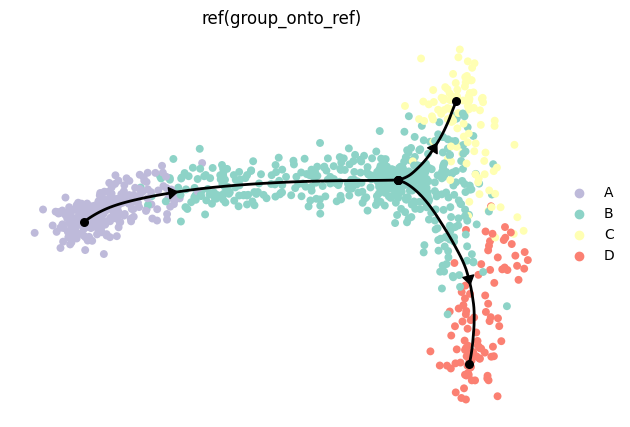

In [5]:
cafe.plot.plot_trajectory(fadata)

添加权重图

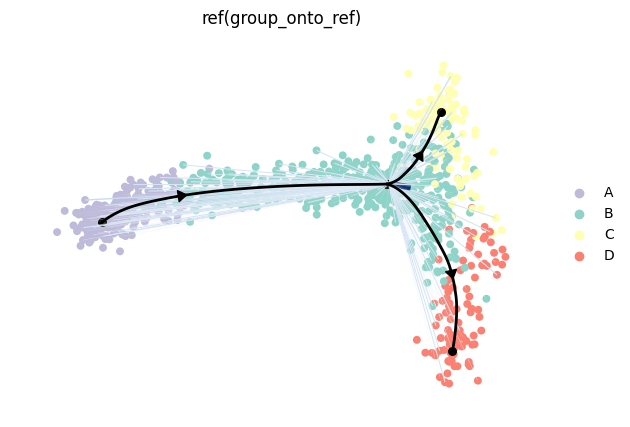

In [ ]:
import matplotlib as plt
import pandas as pd
import networkx as nx

# extract waypoint and distance
waypoint_i = 1
waypoint_distance = fadata.waypoint_wrapper.waypoint_geodesic_distances.iloc[waypoint_i]
waypoint_pos = fadata.get_trajectory_embedding()["wp_segments"].loc[waypoint_i, ["comp_1", "comp_2"]]
# create graph 
basis = fadata.prior_information["basis"]
waypoint_id = f"waypoint{waypoint_i}"
cell_id_list = fadata.obs.index
edge_df = pd.DataFrame(
    data = {
        "from": waypoint_id,
        "to": cell_id_list,
        "weight": 1/waypoint_distance
    }
)
G = nx.from_pandas_edgelist(edge_df, source="from", target="to", edge_attr="weight", create_using=nx.Graph)
pos_dict = dict(zip(cell_id_list, fadata.obsm[basis]))
pos_dict[waypoint_id] = waypoint_pos
# plot
cafe.plot.plot_trajectory(fadata)

# 颜色深浅和粗细代表了边权
nx.draw_networkx_edges(G, pos=pos_dict, edge_color=edge_df["weight"].tolist(), edge_cmap=plt.cm.Blues, width=(edge_df["weight"]/200).tolist())